<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/15_final_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB15 — Figuras Finais e Framework Visual

## 1. Objetivo

Este notebook tem como objetivo produzir as figuras finais do pipeline experimental da dissertação, com foco em comunicação científica, qualificação e defesa.

O NB15 é um notebook **apenas visual**. Ele **não recalcula modelos**, **não executa nova calibração**, **não redefine limiares** e **não reabre decisões metodológicas** já consolidadas nos notebooks NB10 a NB14.

O cenário principal adotado é:

`W5_K24_H12_P1_TRAIN_M2S`

Esse cenário deve ser priorizado em todas as figuras finais. O cenário `W5_K24_H12_P1_TRAIN_P95` pode ser usado apenas como sensibilidade forte ou comparação visual complementar, sem substituir o cenário principal.

---

## 2. Papel do NB15 no pipeline

O NB15 atua como notebook de **síntese visual**. Seu papel é transformar os resultados técnicos dos notebooks anteriores em figuras interpretáveis para a dissertação, a qualificação e a defesa.

A função deste notebook é consolidar visualmente:

- os estados operacionais `NORMAL`, `BEFORE`, `DURING` e `AFTER`;
- os escores de risco temporal produzidos anteriormente;
- os episódios críticos do cenário principal;
- os limiares `tau1` e `tau2` derivados do NB14;
- as classes de ação associadas aos limiares;
- o recorte ampliado da série temporal para apresentação.

O NB15 deve ser entendido como um artefato de apresentação e rastreabilidade, não como novo experimento.

---

## 3. Dependências

O NB15 depende dos resultados estabilizados em:

- **NB10**, para série temporal, estados, episódios e cenário principal;
- **NB11**, para escores preditivos, eventual informação de calibração e registro dos baselines temporais causais, incluindo o EWMA como referência comparativa;
- **NB12**, para preservação da decisão metodológica de manter `train_m2s` como cenário principal;
- **NB14**, para os limiares `tau1` e `tau2`, curva de custo e interpretação operacional.

---

## 4. Entradas esperadas

O script Python associado a este notebook tentará localizar automaticamente os principais artefatos, mas os nomes esperados são preferencialmente:

### 4.1 Artefatos do NB10

- `10_scenario_series_states.parquet`
- `10_scenario_episodes.parquet`
- `10_scenario_advanced_to_nb11.json`
- `10_scenario_diagnostics_summary.json`

### 4.2 Artefatos do NB11

- arquivo de escores ou predições do cenário principal;
- arquivo de calibração ou reliability diagram, se disponível;
- métricas de calibração, se disponíveis.

### 4.3 Artefatos do NB14

- arquivo com curva `custo × tau`;
- arquivo com `tau` ótimo por razão de custo;
- tabela de duração dos episódios e antecipabilidade;
- resumo de decisão operacional.

---

## 5. Princípios metodológicos

### 5.1 Não recalcular modelos

O NB15 não treina, reentreina, recalibra ou substitui modelos. Ele apenas consome escores e artefatos já produzidos.

### 5.2 Não redefinir tau

Os limiares `tau1` e `tau2` devem vir do NB14. A regra conceitual adotada é:

- `tau1`: τ ótimo sob razão `cFP:cFN = 1:20`, representando alerta preventivo sensível;
- `tau2`: τ ótimo sob razão `cFP:cFN = 1:5`, representando escalação operacional mais conservadora.

Se a ordem real dos limiares não for monotônica, o notebook deve registrar a exceção no resumo final e tratar as classes de ação como representação conceitual, não como política ótima automaticamente implementável.

### 5.3 Não poluir a figura principal

A figura principal pode conter muitos elementos. Por isso, o NB15 deve produzir também uma figura recortada e ampliada, com maior legibilidade visual.

---

## 6. Atendimento às solicitações da orientação

A solicitação da professora Cristina e a solicitação do professor Leandro são complementares.

A professora Cristina solicitou uma figura que indique os estágios `NORMAL`, `BEFORE`, `DURING` e `AFTER` com cores distintas. Essa necessidade será atendida pelo **diagrama de estados** e também pela coloração de fundo da série temporal.

O professor Leandro solicitou uma figura recortada da principal, destacando os estados de forma ampliada, para evitar poluição visual. Essa necessidade será atendida pela **série temporal recortada e ampliada**.

Assim, o NB15 deve gerar pelo menos duas figuras centrais:

1. uma figura didática dos estados operacionais com cores distintas;
2. uma figura temporal recortada, ampliada e legível, mostrando estados, escores, episódios e limiares.

---

## 7. Figuras previstas

### Figura 1 — Diagrama de estados operacionais

Finalidade: explicar `NORMAL`, `BEFORE`, `DURING` e `AFTER` com cores distintas e, quando possível, proporções reais observadas no cenário principal.

### Figura 2 — Série temporal principal

Finalidade: mostrar a série temporal do cenário principal com `fail_rate`, estados operacionais, escores, episódios críticos e limiares `tau1` e `tau2`.

### Figura 3 — Série temporal recortada e ampliada

Finalidade: destacar uma região da série que contenha, preferencialmente, a sequência `NORMAL → BEFORE → DURING → AFTER`, com melhor legibilidade para apresentação oral.

### Figura 4 — Classes de ação

Finalidade: representar as zonas interpretativas de decisão:

- monitoramento ordinário;
- alerta preventivo;
- escalação operacional.

### Figura 5 — Curva custo × tau

Finalidade: visualizar o trade-off de decisão sob incerteza e evidenciar a origem dos limiares operacionais.

### Figura 6 — Duração dos episódios × antecipabilidade

Finalidade: resumir achados do NB14 sobre duração dos episódios, taxa de antecipação, recall ou lead time, conforme disponibilidade dos dados.

### Figura 7 — Curva de calibração

Finalidade: mostrar, quando disponível, a relação entre escore previsto e frequência observada, antes e/ou depois de calibração.

---

## 8. Saídas esperadas

O NB15 deve produzir, quando os artefatos estiverem disponíveis:

- `15_fig_01_diagrama_estados.png`
- `15_fig_01_diagrama_estados.pdf`
- `15_fig_02_serie_temporal_principal.png`
- `15_fig_02_serie_temporal_principal.pdf`
- `15_fig_03_serie_temporal_recorte_ampliado.png`
- `15_fig_03_serie_temporal_recorte_ampliado.pdf`
- `15_fig_04_classes_acao.png`
- `15_fig_04_classes_acao.pdf`
- `15_fig_05_custo_tau.png`
- `15_fig_05_custo_tau.pdf`
- `15_fig_06_duracao_antecipabilidade.png`
- `15_fig_06_duracao_antecipabilidade.pdf`
- `15_fig_07_calibracao.png`
- `15_fig_07_calibracao.pdf`
- `15_visual_framework_manifest.csv`
- `15_visual_framework_summary.json`

---

## 9. Critérios de validação

Ao final, conferir se:

1. o cenário principal permaneceu `W5_K24_H12_P1_TRAIN_M2S`;
2. o notebook não recalculou modelos;
3. `tau1` e `tau2` foram extraídos do NB14;
4. a figura de estados usa cores distintas para os quatro estados;
5. o recorte ampliado foi produzido;
6. os arquivos foram gravados em alta resolução;
7. o manifesto registra todos os arquivos produzidos;
8. o resumo final registra avisos sobre artefatos ausentes ou incompatíveis.

---

## 10. Interpretação esperada

As figuras do NB15 devem reforçar a narrativa central da dissertação:

- a criticidade é modelada como fenômeno temporal estruturado;
- os estados operacionais ajudam a explicar a evolução do sistema;
- os escores devem ser lidos como risco temporal relativo;
- o EWMA causal do NB11 permanece como baseline temporal suavizado de referência, sem substituir o escore operacional consolidado;
- os limiares `tau1` e `tau2` conectam o modelo preditivo à decisão sob incerteza;
- o recorte ampliado permite comunicar esses achados sem excesso de informação visual.

---

## 11. Conclusão

O NB15 fecha a etapa visual do pipeline, preparando as figuras definitivas para dissertação, qualificação e defesa. Seu valor está na clareza, rastreabilidade e capacidade de comunicação dos resultados, não na abertura de novos experimentos.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[2026-05-27 20:47:30] ====================================================================================================
[2026-05-27 20:47:30] NB15 — Figuras Finais e Framework Visual
[2026-05-27 20:47:30] RUN_TIMESTAMP = 2026-05-27 20:47:28
[2026-05-27 20:47:30] IN_COLAB = True
[2026-05-27 20:47:30] BASE_DIR = /content/drive/MyDrive/Mestrado
[2026-05-27 20:47:30] REPORTS_DIR = /content/drive/MyDrive/Mestrado/04-reports
[2026-05-27 20:47:30] FIGURES_DIR = /content/drive/MyDrive/Mestrado/04-reports/figures_nb15
[2026-05-27 20:47:30] ARTIFACTS_DIR = /content/drive/MyDrive/Mestrado/04-reports
[2026-05-27 20:47:30] ====================================================================================================
[2026-05-27 20:47:30] Artefatos localizados para o NB15:
[2026-05-27 20:47:30] series_states: /content/drive/MyDrive/Mestrado/04-reports/10_scenario_

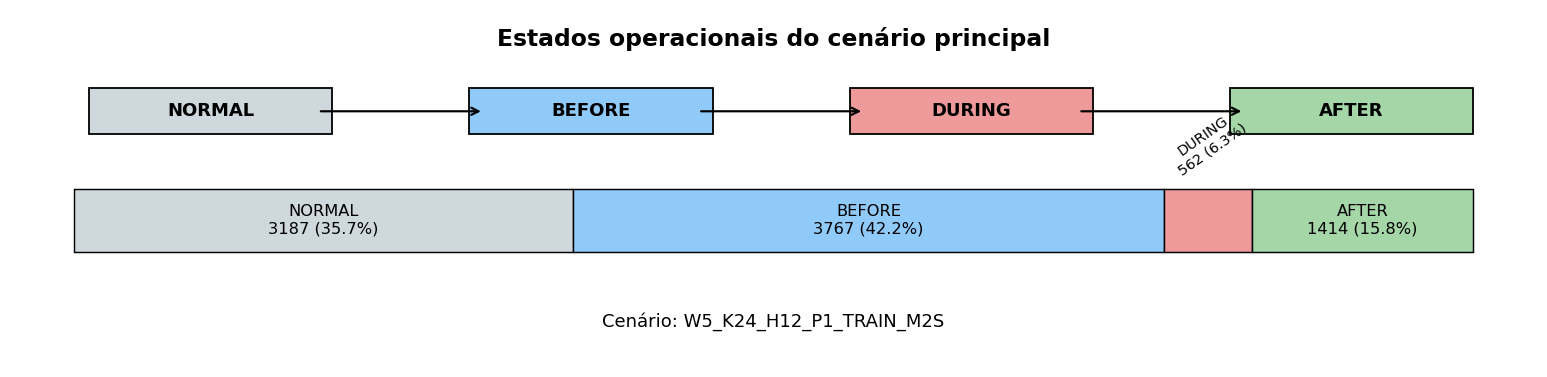

[2026-05-27 20:47:31] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_01_diagrama_estados.png


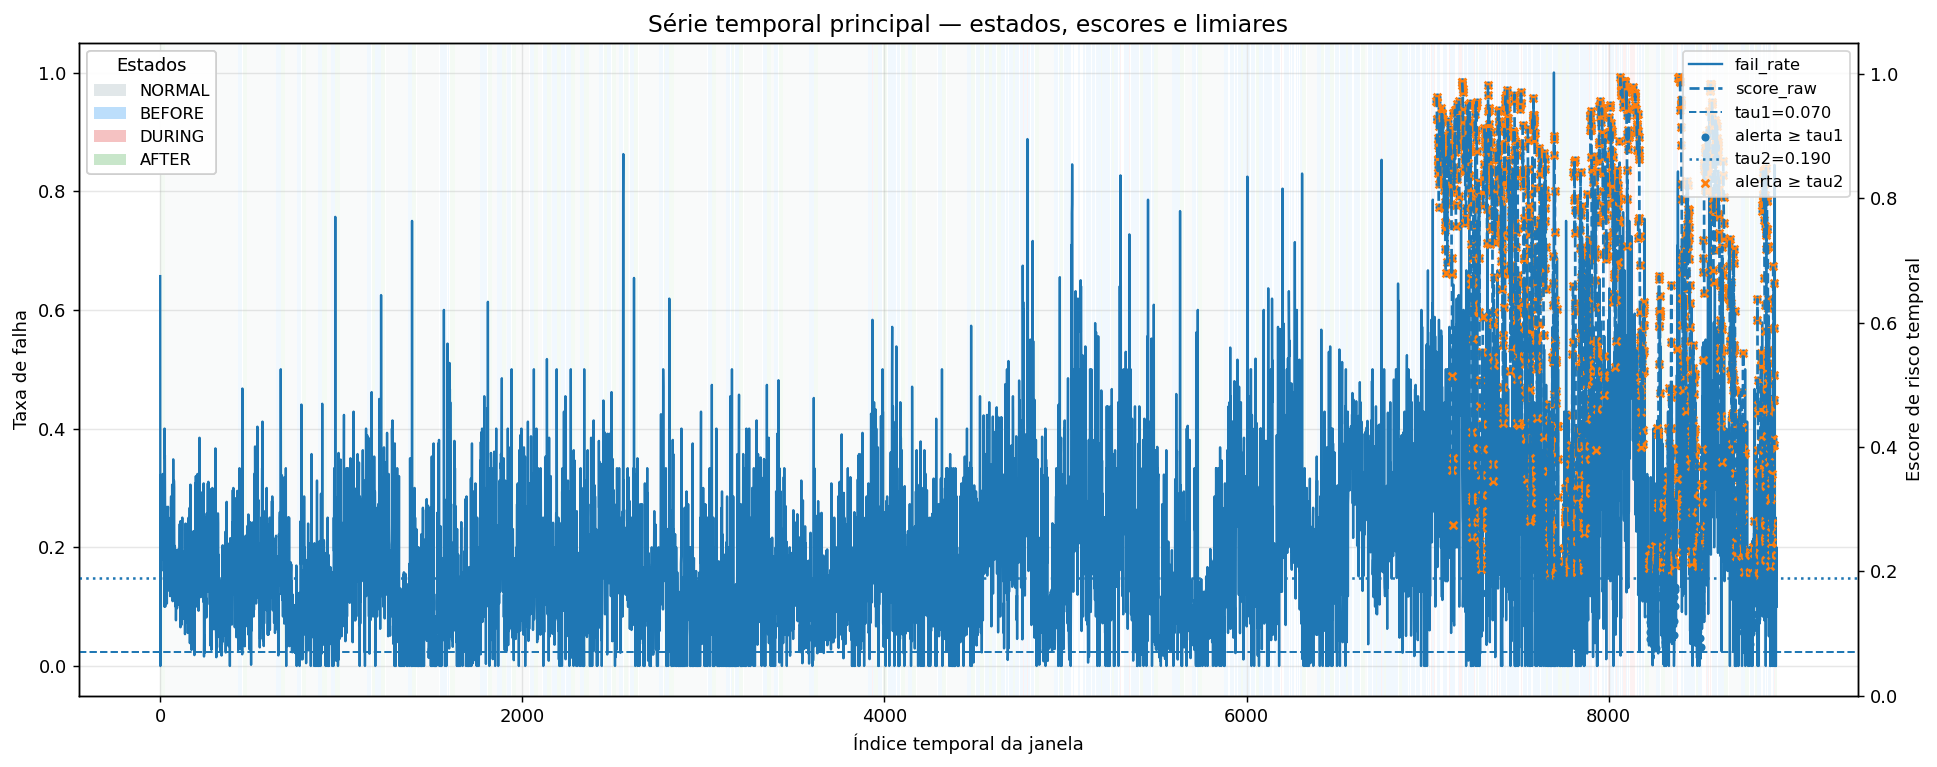

[2026-05-27 20:47:37] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_02_serie_temporal_principal.png


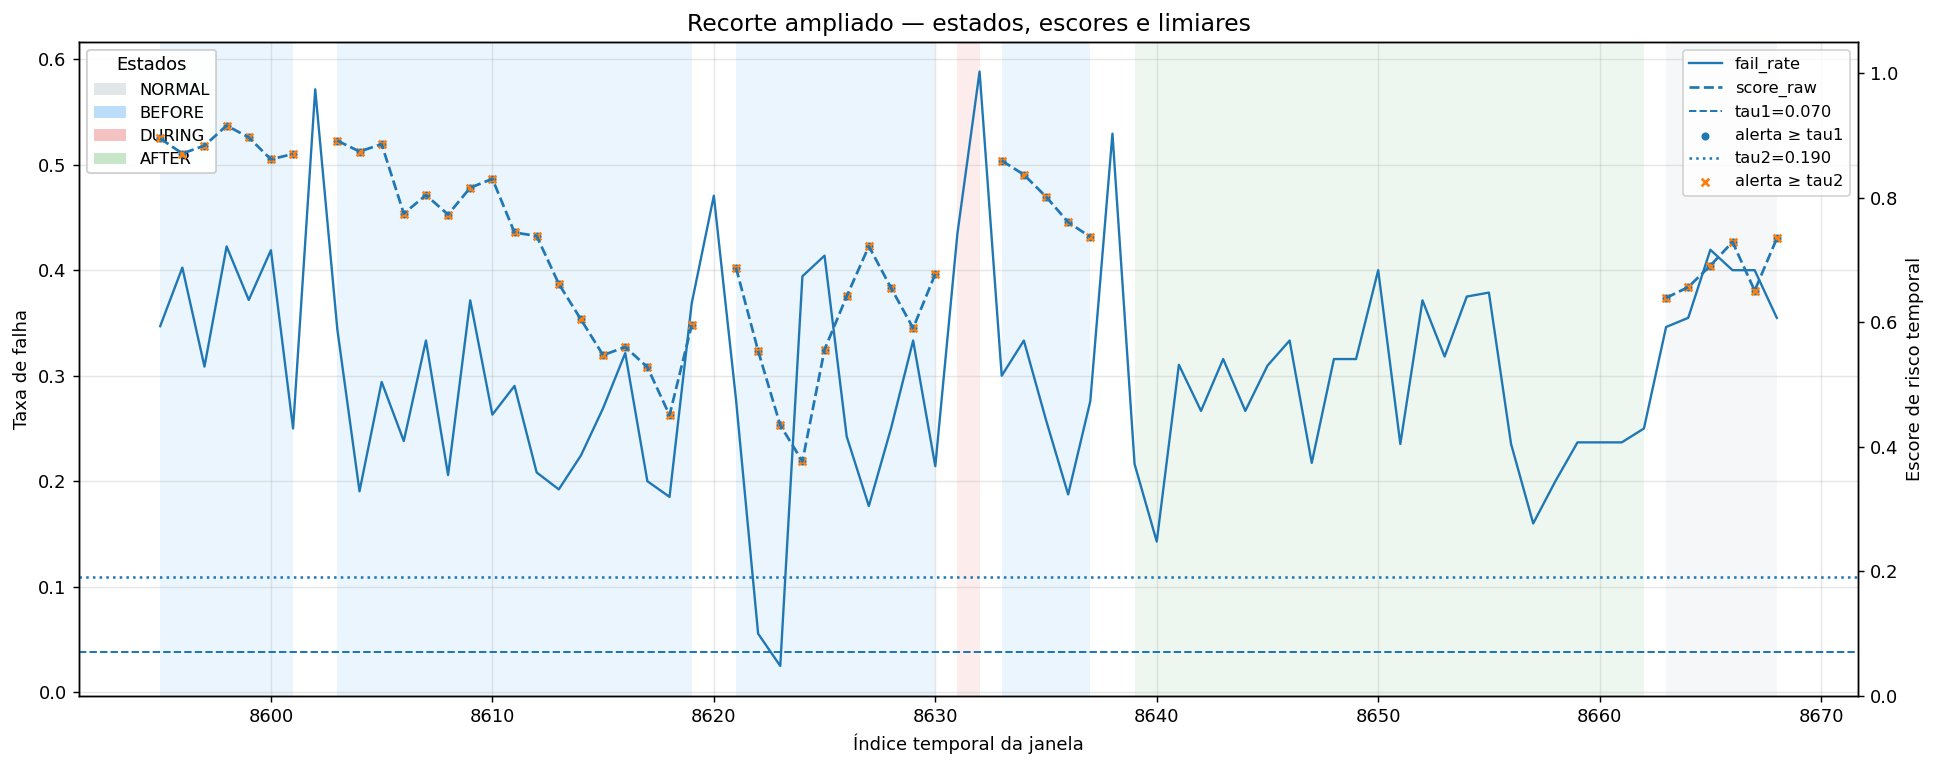

[2026-05-27 20:47:40] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_03_serie_temporal_recorte_ampliado.png


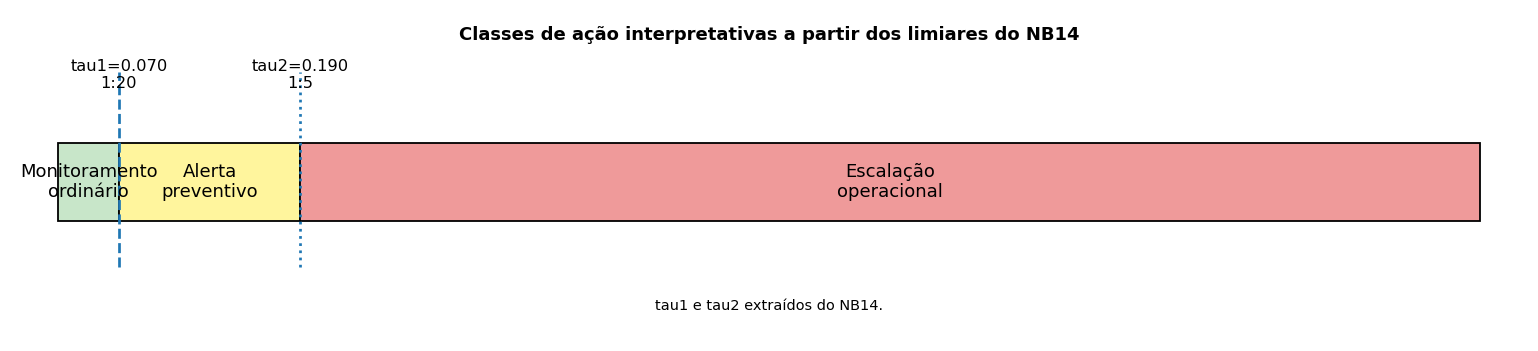

[2026-05-27 20:47:40] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_04_classes_acao.png


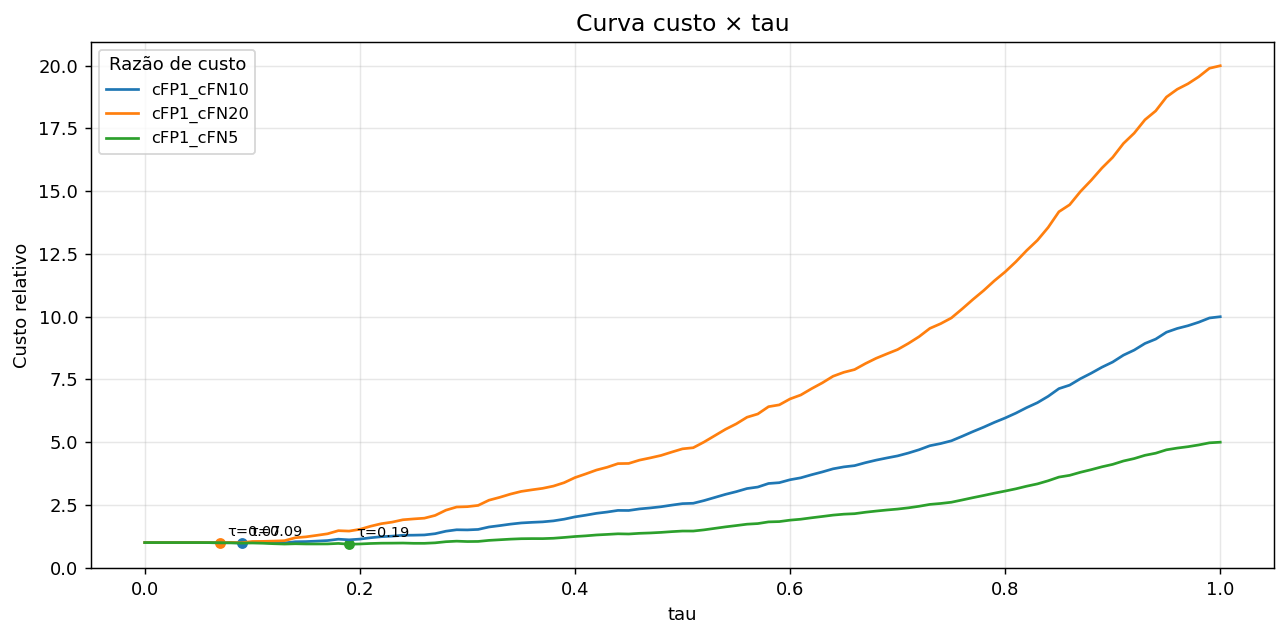

[2026-05-27 20:47:41] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_05_custo_tau.png


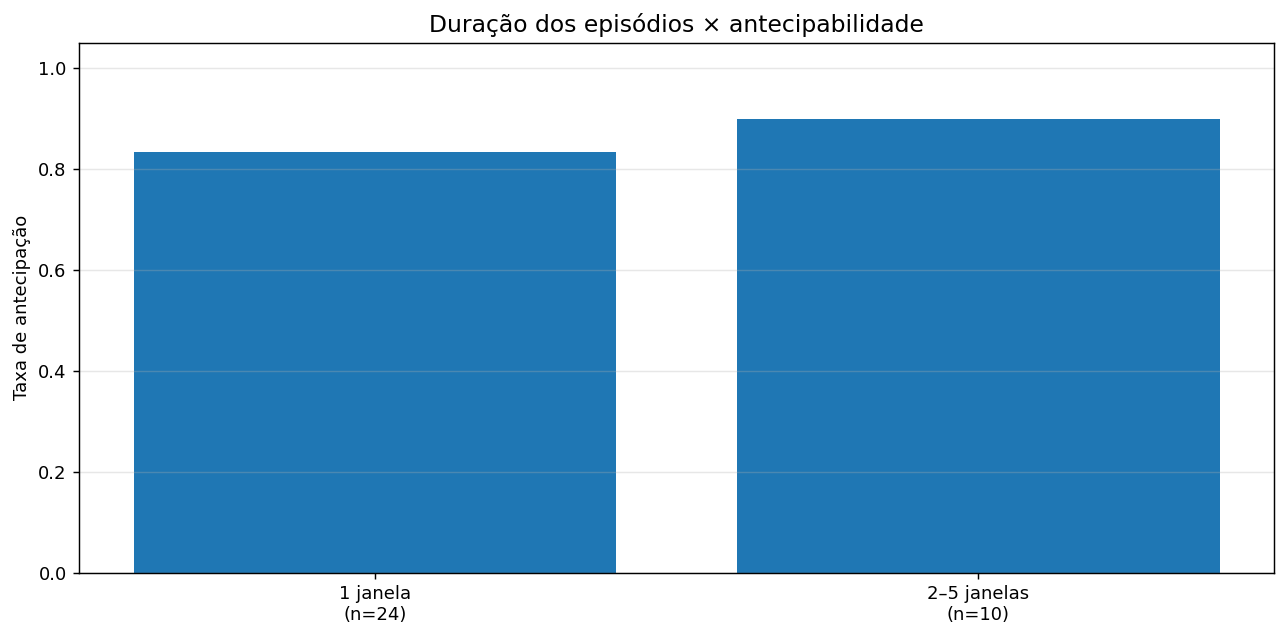

[2026-05-27 20:47:42] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_06_duracao_antecipabilidade.png


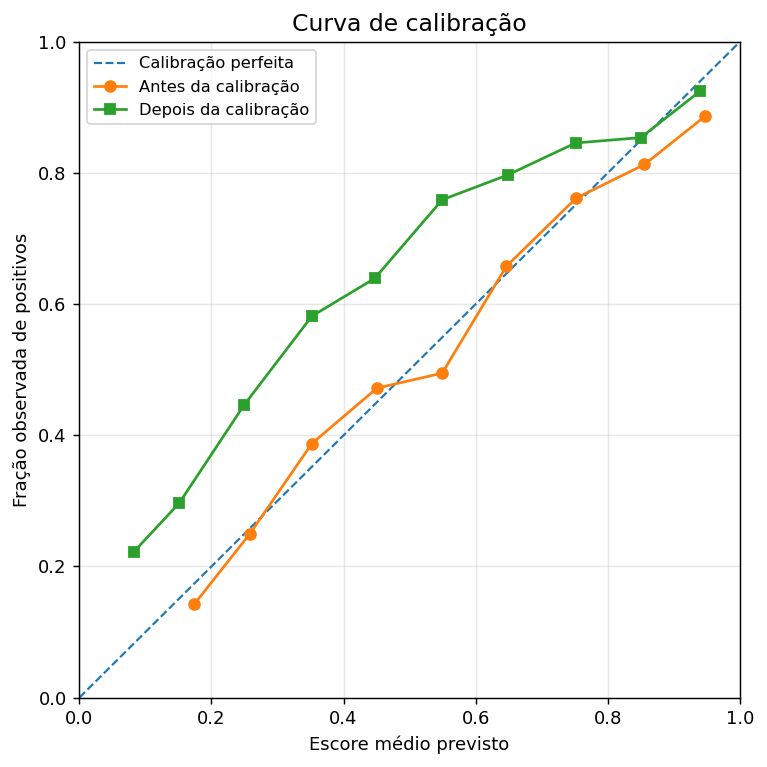

[2026-05-27 20:47:43] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_07_calibracao.png


,figure_type,filename,path
0,state_diagram,15_fig_01_diagrama_estados.png,/content/drive/MyDrive/Mestrado/04-reports/fig...
1,state_diagram,15_fig_01_diagrama_estados.pdf,/content/drive/MyDrive/Mestrado/04-reports/fig...
2,main_temporal_series,15_fig_02_serie_temporal_principal.png,/content/drive/MyDrive/Mestrado/04-reports/fig...
3,main_temporal_series,15_fig_02_serie_temporal_principal.pdf,/content/drive/MyDrive/Mestrado/04-reports/fig...
4,zoom_temporal_series,15_fig_03_serie_temporal_recorte_ampliado.png,/content/drive/MyDrive/Mestrado/04-reports/fig...
5,zoom_temporal_series,15_fig_03_serie_temporal_recorte_ampliado.pdf,/content/drive/MyDrive/Mestrado/04-reports/fig...
6,action_classes,15_fig_04_classes_acao.png,/content/drive/MyDrive/Mestrado/04-reports/fig...
7,action_classes,15_fig_04_classes_acao.pdf,/content/drive/MyDrive/Mestrado/04-reports/fig...
8,cost_tau,15_fig_05_custo_tau.png,/content/drive/MyDrive/Mestrado/04-reports/fig...
9,cost_tau,15_fig_05_custo_tau.pdf,/content/drive/MyDrive/Mestrado/04-reports/fig...


NB15 concluído.
Cenário principal: W5_K24_H12_P1_TRAIN_M2S
Diretório de figuras: /content/drive/MyDrive/Mestrado/04-reports/figures_nb15
Diretório dos artefatos de controle: /content/drive/MyDrive/Mestrado/04-reports
Manifesto: /content/drive/MyDrive/Mestrado/04-reports/15_visual_framework_manifest.csv
Resumo JSON: /content/drive/MyDrive/Mestrado/04-reports/15_visual_framework_summary.json
Figuras criadas:
 - /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_01_diagrama_estados.png
 - /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_01_diagrama_estados.pdf
 - /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_02_serie_temporal_principal.png
 - /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_02_serie_temporal_principal.pdf
 - /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_03_serie_temporal_recorte_ampliado.png
 - /content/drive/MyDrive/Mestrado/04-reports/figures_nb15/15_fig_03_serie_temporal_recorte_ampliado.pdf
 - /

In [3]:
"""
NB15 — Figuras Finais e Framework Visual

Script/notebook de síntese visual para a dissertação.

Características principais:
- não recalcula modelos;
- não reabre seleção de cenário;
- prioriza W5_K24_H12_P1_TRAIN_M2S;
- extrai tau1 e tau2 dos artefatos do NB14;
- produz figuras finais com estados e recorte ampliado;
- gera manifesto e resumo JSON de rastreabilidade.

Uso recomendado no Colab:
1. Monte o Google Drive.
2. Ajuste BASE_DIR se necessário.
3. Execute o script ou cole as células em um notebook NB15.
"""

from __future__ import annotations

import json
import warnings
from datetime import datetime
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

try:
    from IPython.display import display
except Exception:  # execução fora de notebook
    display = None

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURAÇÃO GERAL — padrão NB10–NB14
# ============================================================

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")


def now_str() -> str:
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def log(msg: str) -> None:
    print(f"[{now_str()}] {msg}", flush=True)


# Detecção e montagem automática do Google Drive no Colab, seguindo o padrão dos notebooks anteriores.
def detect_colab() -> bool:
    try:
        import google.colab  # type: ignore  # noqa: F401
        return True
    except Exception:
        return False


IN_COLAB = detect_colab()
if IN_COLAB:
    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive")
    except Exception as exc:
        log(f"[AVISO] Não foi possível montar o Google Drive automaticamente: {exc}")

BASE_DIR = (
    Path("/content/drive/MyDrive/Mestrado")
    if Path("/content/drive/MyDrive/Mestrado").exists()
    else Path.cwd()
)

DATA_DIR = BASE_DIR / "02-datasets"
FEATURES_DIR = DATA_DIR / "03-features"
MODELS_DIR = BASE_DIR / "03-models"
REPORTS_DIR = BASE_DIR / "04-reports"
FIGURES_DIR = REPORTS_DIR / "figures_nb15"
ARTIFACTS_DIR = REPORTS_DIR  # arquivos de controle do NB15 ficam em 04-reports, não em figures_nb15

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_MAIN = "W5_K24_H12_P1_TRAIN_M2S"
SCENARIO_SENSITIVITY = "W5_K24_H12_P1_TRAIN_P95"
EWMA_BASELINE_NOTE = (
    "O EWMA causal do NB11 é tratado como baseline temporal suavizado comparativo. "
    "Ele não substitui o escore operacional selecionado para a análise decisória do NB14 "
    "e não gera nova figura obrigatória no NB15."
)
DISPLAY_FIGURES_INLINE = True

STATE_COLORS = {
    "NORMAL": "#cfd8dc",  # cinza claro
    "BEFORE": "#90caf9",  # azul claro
    "DURING": "#ef9a9a",  # vermelho claro
    "AFTER": "#a5d6a7",   # verde claro
}

STATE_ORDER = ["NORMAL", "BEFORE", "DURING", "AFTER"]

SEARCH_ROOTS = [
    REPORTS_DIR,
    REPORTS_DIR / "nb10",
    REPORTS_DIR / "nb11",
    REPORTS_DIR / "nb12",
    REPORTS_DIR / "nb13",
    REPORTS_DIR / "nb14",
    FEATURES_DIR,
    MODELS_DIR,
    BASE_DIR,
]

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["font.size"] = 10

log("=" * 100)
log("NB15 — Figuras Finais e Framework Visual")
log(f"RUN_TIMESTAMP = {RUN_TIMESTAMP}")
log(f"IN_COLAB = {IN_COLAB}")
log(f"BASE_DIR = {BASE_DIR}")
log(f"REPORTS_DIR = {REPORTS_DIR}")
log(f"FIGURES_DIR = {FIGURES_DIR}")
log(f"ARTIFACTS_DIR = {ARTIFACTS_DIR}")
log("=" * 100)


# ============================================================
# 2. ESTRUTURAS AUXILIARES
# ============================================================

@dataclass
class ArtifactSet:
    series_states: Optional[Path] = None
    episodes: Optional[Path] = None
    scores: Optional[Path] = None
    cost_tau: Optional[Path] = None
    cost_curve: Optional[Path] = None
    duration_anticipability: Optional[Path] = None
    calibration: Optional[Path] = None


@dataclass
class TauInfo:
    tau1: Optional[float]
    tau2: Optional[float]
    source: Optional[str]
    note: str


# ============================================================
# 3. FUNÇÕES DE CAMINHO E LEITURA
# ============================================================

def resolve_base_dir() -> Path:
    """Mantido por compatibilidade; BASE_DIR já foi definido após tentativa de montagem do Drive."""
    return BASE_DIR


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def recursive_find(base: Path, patterns: Sequence[str]) -> List[Path]:
    found: List[Path] = []
    for pattern in patterns:
        found.extend(base.rglob(pattern))
    unique: List[Path] = []
    seen = set()
    for path in found:
        resolved = path.resolve()
        if resolved not in seen:
            seen.add(resolved)
            unique.append(path)
    return unique


def choose_file(candidates: Sequence[Path], preferred_tokens: Sequence[str]) -> Optional[Path]:
    if not candidates:
        return None

    def score(path: Path) -> Tuple[int, int, str]:
        name = path.name.lower()
        token_score = sum(1 for token in preferred_tokens if token.lower() in name)
        return token_score, -len(name), name

    return sorted(candidates, key=score, reverse=True)[0]


def load_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Formato não suportado: {path}")


def save_json(obj: Dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


# ============================================================
# 4. LOCALIZAÇÃO DE ARTEFATOS
# ============================================================

def find_file(filename: str, required: bool = False, search_roots: Optional[Sequence[Path]] = None) -> Optional[Path]:
    """Localiza arquivo pelo mesmo padrão usado no NB14: busca direta e depois recursiva."""
    roots = list(search_roots or SEARCH_ROOTS)

    direct_candidates = [Path(root) / filename for root in roots]
    for candidate in direct_candidates:
        if candidate.exists():
            return candidate

    matches: List[Path] = []
    for root in roots:
        root = Path(root)
        if root.exists():
            matches.extend(root.rglob(filename))

    if matches:
        return sorted(matches, key=lambda x: x.stat().st_mtime, reverse=True)[0]

    if required:
        msg = "Arquivo obrigatório não encontrado: " + filename + "\nCandidatos diretos:\n"
        msg += "\n".join(str(p) for p in direct_candidates)
        raise FileNotFoundError(msg)
    return None


def first_available_file(filenames: Sequence[str], required: bool = False) -> Optional[Path]:
    for filename in filenames:
        found = find_file(filename, required=False)
        if found is not None:
            return found
    if required:
        raise FileNotFoundError("Nenhum dos arquivos esperados foi localizado: " + ", ".join(filenames))
    return None


def locate_artifacts(base_dir: Path) -> ArtifactSet:
    """Localiza artefatos canônicos usando o mesmo padrão dos notebooks NB10–NB14."""

    # Entradas NB10
    series_states = first_available_file([
        "10_scenario_series_states.parquet",
    ])
    episodes = first_available_file([
        "10_scenario_episodes.parquet",
    ])

    # Escores: prioriza o artefato já selecionado pelo NB14, pois ele respeita a decisão NB11/NB13.
    scores = first_available_file([
        "14_scores_selected.parquet",
        "11_scores_calibrated.parquet",
        "11_scores_raw.parquet",
        "13_lstm_scores.parquet",
        "12_scores_sensitivity_fixed.parquet",
    ])

    # NB14: tau ótimo e curva completa são artefatos distintos.
    optimal_tau = first_available_file([
        "14_optimal_tau_by_cost.csv",
    ])
    cost_curve = first_available_file([
        "14_cost_curve.csv",
    ])

    duration_anticipability = first_available_file([
        "14_episode_duration_summary.csv",
        "14_episode_anticipability.csv",
        "14_episode_anticipability_by_tau.csv",
    ])

    calibration = first_available_file([
        "11_calibration_summary.csv",
        "11_reliability_diagram.csv",
        "11_calibration_curve.csv",
    ])

    artifacts = ArtifactSet(
        series_states=series_states,
        episodes=episodes,
        scores=scores,
        cost_tau=optimal_tau or cost_curve,
        cost_curve=cost_curve or optimal_tau,
        duration_anticipability=duration_anticipability,
        calibration=calibration,
    )

    log("Artefatos localizados para o NB15:")
    for name, path in artifacts.__dict__.items():
        log(f"{name}: {path}")

    return artifacts


# ============================================================
# 5. INFERÊNCIA DE COLUNAS
# ============================================================

def lower_map(df: pd.DataFrame) -> Dict[str, str]:
    return {str(c).lower(): c for c in df.columns}


def first_col(df: pd.DataFrame, names: Sequence[str]) -> Optional[str]:
    lm = lower_map(df)
    for name in names:
        if name.lower() in lm:
            return lm[name.lower()]
    return None


def contains_col(df: pd.DataFrame, tokens: Sequence[str]) -> Optional[str]:
    for col in df.columns:
        lower = str(col).lower()
        if any(token.lower() in lower for token in tokens):
            return col
    return None


def scenario_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["scenario_label", "scenario", "scenario_id", "scenario_name", "cenario"])


def state_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["state", "state_label", "operational_state", "estado", "stage"]) or contains_col(df, ["state", "estado", "stage"])


def time_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["bucket_id", "bucket_start_us", "bucket_start", "time", "timestamp", "t_rel_us", "window_id"])


def fail_rate_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["fail_rate", "failure_rate", "taxa_falha"])


def score_cols(df: pd.DataFrame) -> Tuple[Optional[str], Optional[str]]:
    calibrated = first_col(df, ["score_calibrated", "y_score_calibrated", "prob_calibrated", "p_calibrated", "score_platt"])
    raw = first_col(df, ["score", "y_score", "prob", "probability", "y_proba", "score_raw", "pred_score"])

    if calibrated is None:
        calibrated = contains_col(df, ["calibrated", "calib", "platt"])

    if raw is None:
        for col in df.columns:
            lower = str(col).lower()
            if ("score" in lower or "prob" in lower or "proba" in lower) and col != calibrated:
                raw = col
                break

    return calibrated, raw


def target_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["y_true", "target", "y", "label", "target_bin"])


def tau_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["tau", "threshold", "limiar"])


def ratio_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["cost_label", "cost_ratio", "ratio", "cfp_cfn", "cost_relation", "ratio_label"])


def cost_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["cost", "c_tau", "total_cost", "custo"])


def duration_band_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["duration_bucket", "duration_band", "episode_duration_bucket", "faixa_duracao", "duration_group", "band", "faixa"])


def anticipation_rate_col(df: pd.DataFrame) -> Optional[str]:
    # NB14 grava a taxa por faixa como episode_recall_by_duration.
    # Mantém aliases genéricos para eventuais variações futuras.
    return first_col(
        df,
        [
            "episode_recall_by_duration",
            "episode_anticipation_rate_full_horizon",
            "episode_anticipation_rate_any_score",
            "anticipation_rate",
            "episode_anticipation_rate",
            "coverage",
            "recall",
            "rate",
            "taxa_antecipacao",
        ],
    )


def count_col(df: pd.DataFrame) -> Optional[str]:
    return first_col(df, ["n", "count", "episodes", "num_episodes", "qtd"])


# ============================================================
# 6. PREPARAÇÃO DOS DADOS
# ============================================================

def filter_scenario(df: pd.DataFrame, scenario: str) -> pd.DataFrame:
    sc = scenario_col(df)
    if sc is None:
        return df.copy()
    mask = df[sc].astype(str).str.upper().eq(scenario.upper())
    filtered = df.loc[mask].copy()
    return filtered if not filtered.empty else df.copy()


def standardize_state(value) -> str:
    v = str(value).strip().upper()
    aliases = {
        "N": "NORMAL",
        "NORMAL": "NORMAL",
        "BEFORE": "BEFORE",
        "PRE": "BEFORE",
        "PRÉ": "BEFORE",
        "DURING": "DURING",
        "CRITICAL": "DURING",
        "CRITICO": "DURING",
        "CRÍTICO": "DURING",
        "AFTER": "AFTER",
        "POST": "AFTER",
        "PÓS": "AFTER",
    }
    return aliases.get(v, v)


def prepare_main_series(artifacts: ArtifactSet) -> pd.DataFrame:
    if artifacts.series_states is None:
        raise FileNotFoundError("Não foi localizado o artefato 10_scenario_series_states.parquet ou equivalente.")

    df = load_table(artifacts.series_states)
    df = filter_scenario(df, SCENARIO_MAIN)

    sc = state_col(df)
    tc = time_col(df)
    frc = fail_rate_col(df)

    if sc is None:
        raise ValueError("Não foi possível identificar a coluna de estados operacionais.")
    if tc is None:
        raise ValueError("Não foi possível identificar a coluna temporal.")

    df = df.sort_values(tc).reset_index(drop=True).copy()
    df["state_std"] = df[sc].map(standardize_state)
    df["plot_index"] = np.arange(len(df))
    df["time_key"] = df[tc]

    if frc is not None:
        df["fail_rate_std"] = pd.to_numeric(df[frc], errors="coerce")
    else:
        df["fail_rate_std"] = np.nan

    return df


def merge_scores(main_df: pd.DataFrame, artifacts: ArtifactSet) -> pd.DataFrame:
    if artifacts.scores is None:
        return main_df.copy()

    try:
        scores = load_table(artifacts.scores)
    except Exception:
        return main_df.copy()

    scores = filter_scenario(scores, SCENARIO_MAIN)
    tc = time_col(scores)
    if tc is None:
        return main_df.copy()

    cal, raw = score_cols(scores)
    tgt = target_col(scores)

    keep = [tc]
    rename = {tc: "time_key"}

    if cal is not None:
        keep.append(cal)
        rename[cal] = "score_calibrated"
    if raw is not None and raw not in keep:
        keep.append(raw)
        rename[raw] = "score_raw"
    if tgt is not None and tgt not in keep:
        keep.append(tgt)
        rename[tgt] = "y_true"

    if len(keep) == 1:
        return main_df.copy()

    scores2 = scores[keep].rename(columns=rename).drop_duplicates(subset=["time_key"])
    merged = main_df.merge(scores2, on="time_key", how="left")

    score_available = [c for c in ["score_calibrated", "score_raw"] if c in merged.columns]
    if score_available and merged[score_available].notna().any(axis=1).mean() < 0.05 and len(scores2) == len(main_df):
        # fallback por posição, útil quando o score foi exportado após recortes e sem bucket_id compatível
        merged = main_df.copy().reset_index(drop=True)
        scores2 = scores2.reset_index(drop=True)
        for col in ["score_calibrated", "score_raw", "y_true"]:
            if col in scores2.columns and len(scores2[col]) == len(merged):
                merged[col] = scores2[col].values

    return merged


def load_tau_info(artifacts: ArtifactSet) -> Tuple[TauInfo, Optional[pd.DataFrame]]:
    if artifacts.cost_tau is None:
        return TauInfo(None, None, None, "Artefato de custo × tau do NB14 não localizado."), None

    df = load_table(artifacts.cost_tau)
    df = filter_scenario(df, SCENARIO_MAIN)

    cost_curve_df = None
    if getattr(artifacts, "cost_curve", None) is not None:
        try:
            cost_curve_df = filter_scenario(load_table(artifacts.cost_curve), SCENARIO_MAIN)
        except Exception:
            cost_curve_df = None

    tc = tau_col(df)
    rc = ratio_col(df)
    cc = cost_col(df)

    if tc is None or rc is None:
        return TauInfo(None, None, str(artifacts.cost_tau), "Arquivo localizado, mas colunas de tau/razão não foram identificadas."), (cost_curve_df if cost_curve_df is not None else df)

    work = df.copy()
    work[tc] = pd.to_numeric(work[tc], errors="coerce")
    if cc is not None:
        work[cc] = pd.to_numeric(work[cc], errors="coerce")

    work["ratio_std"] = work[rc].astype(str).str.upper().str.replace(" ", "", regex=False)

    def best_tau(*ratio_tokens: str) -> Optional[float]:
        mask = pd.Series(False, index=work.index)
        for token in ratio_tokens:
            token_std = str(token).upper().replace(" ", "")
            mask = mask | work["ratio_std"].str.contains(token_std, regex=False, na=False)
        sub = work[mask].copy()
        if sub.empty:
            return None
        if cc is not None:
            sub = sub.sort_values(cc, na_position="last")
        return float(sub.iloc[0][tc]) if pd.notna(sub.iloc[0][tc]) else None

    # NB14 usa cost_label como cFP1_cFN20, cFP1_cFN10, cFP1_cFN5.
    # Também aceita a grafia conceitual 1:20 / 1:5, caso o CSV tenha sido renomeado.
    tau1 = best_tau("1:20", "CFP1_CFN20", "CFP:CFN=1:20")
    tau2 = best_tau("1:5", "CFP1_CFN5", "CFP:CFN=1:5")

    note = "tau1 e tau2 extraídos do NB14."
    if tau1 is None or tau2 is None:
        note = "Não foi possível extrair tau1 e/ou tau2 das razões 1:20 e 1:5."
    elif tau1 > tau2:
        note = "Exceção de monotonicidade: tau1 > tau2. Classes de ação devem ser lidas como diagrama conceitual."

    return TauInfo(tau1, tau2, str(artifacts.cost_tau), note), (cost_curve_df if cost_curve_df is not None else df)


def load_duration_data(artifacts: ArtifactSet) -> Optional[pd.DataFrame]:
    """Carrega o resumo de duração/antecipabilidade produzido pelo NB14.

    O NB14 canônico grava 14_episode_duration_summary.csv com colunas como:
    - scenario_label
    - tau
    - tau_role
    - duration_bucket
    - duration_bucket_order
    - n_evaluable_full_horizon
    - episode_recall_by_duration
    - lead_time_minutes_median

    Reconhece os nomes reais do NB14 e, por padrão, usa tau_role == reference_0.50,
    exatamente como o NB14 faz na figura de duração × antecipabilidade.
    """
    if artifacts.duration_anticipability is None:
        return None
    try:
        df = load_table(artifacts.duration_anticipability)
    except Exception as exc:
        log(f"[AVISO] Não foi possível ler o artefato de duração/antecipabilidade: {exc}")
        return None

    df = filter_scenario(df, SCENARIO_MAIN)

    # Se o CSV for o 14_episode_duration_summary.csv, prioriza o recorte tau=0,50.
    tau_role = first_col(df, ["tau_role"])
    if tau_role is not None:
        preferred = df[df[tau_role].astype(str).str.lower().eq("reference_0.50")].copy()
        if not preferred.empty:
            df = preferred

    # Se houver várias linhas por tau sem tau_role, tenta usar tau=0.50.
    tau_c = tau_col(df)
    if tau_c is not None and "tau_role" not in [str(c).lower() for c in df.columns]:
        tau_numeric = pd.to_numeric(df[tau_c], errors="coerce")
        preferred = df[np.isclose(tau_numeric, 0.50, atol=1e-9)].copy()
        if not preferred.empty:
            df = preferred

    bc = duration_band_col(df)
    rc = anticipation_rate_col(df)
    nc = first_col(df, ["n_evaluable_full_horizon", "n_total_episodes", "n", "count", "episodes", "num_episodes", "qtd"])
    order_c = first_col(df, ["duration_bucket_order"])
    lead_c = first_col(df, ["lead_time_minutes_median", "lead_time_minutes_mean"])

    if bc is None or rc is None:
        log(
            "[AVISO] Artefato de duração localizado, mas colunas esperadas não foram identificadas. "
            f"Colunas disponíveis: {list(df.columns)}"
        )
        return None

    out = pd.DataFrame({
        "duration_band": df[bc].astype(str),
        "anticipation_rate": pd.to_numeric(df[rc], errors="coerce"),
    })
    out["n"] = pd.to_numeric(df[nc], errors="coerce") if nc is not None else np.nan
    out["duration_bucket_order"] = pd.to_numeric(df[order_c], errors="coerce") if order_c is not None else np.arange(len(out))
    if lead_c is not None:
        out["lead_time_minutes_median"] = pd.to_numeric(df[lead_c], errors="coerce")

    out = out.dropna(subset=["anticipation_rate"]).sort_values("duration_bucket_order")

    # Garantia visual: a Figura 6 deve apresentar uma única barra por faixa de duração
    # no cenário principal. Se algum artefato futuro ainda trouxer duplicidades, consolida
    # as linhas equivalentes por média ponderada pela quantidade de episódios, quando disponível.
    if out["duration_band"].duplicated().any():
        rows = []
        for duration_band, grp in out.groupby("duration_band", sort=False):
            grp = grp.copy()
            weights = pd.to_numeric(grp.get("n", pd.Series(index=grp.index, dtype=float)), errors="coerce")
            rates = pd.to_numeric(grp["anticipation_rate"], errors="coerce")
            valid_weighted = weights.notna() & (weights > 0) & rates.notna()
            if valid_weighted.any():
                rate = float(np.average(rates[valid_weighted], weights=weights[valid_weighted]))
                n_value = float(weights[valid_weighted].sum())
            else:
                rate = float(rates.mean())
                n_value = np.nan

            row = {
                "duration_band": str(duration_band),
                "anticipation_rate": rate,
                "n": n_value,
                "duration_bucket_order": float(pd.to_numeric(grp["duration_bucket_order"], errors="coerce").min()),
            }
            if "lead_time_minutes_median" in grp.columns:
                row["lead_time_minutes_median"] = float(pd.to_numeric(grp["lead_time_minutes_median"], errors="coerce").median())
            rows.append(row)

        out = pd.DataFrame(rows).sort_values("duration_bucket_order")

    return out


def empirical_calibration(y_true: pd.Series, y_score: pd.Series, bins: int = 10) -> pd.DataFrame:
    y = pd.to_numeric(y_true, errors="coerce")
    s = pd.to_numeric(y_score, errors="coerce")
    mask = y.notna() & s.notna()
    y = y[mask].astype(float)
    s = s[mask].astype(float)

    if len(y) == 0:
        return pd.DataFrame(columns=["mean_pred", "frac_pos", "count"])

    cuts = pd.cut(s, bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    grouped = pd.DataFrame({"y": y, "s": s, "bin": cuts}).groupby("bin", observed=True)
    return grouped.agg(mean_pred=("s", "mean"), frac_pos=("y", "mean"), count=("y", "size")).reset_index(drop=True)


def find_optional_file(base_dir, filename):
    candidates = [
        REPORTS_DIR / filename if "REPORTS_DIR" in globals() else None,
        base_dir / "04-reports" / filename,
        base_dir / filename,
    ]

    for p in candidates:
        if p is not None and Path(p).exists():
            return Path(p)

    for root in [base_dir / "04-reports", base_dir]:
        if Path(root).exists():
            matches = sorted(
                Path(root).rglob(filename),
                key=lambda x: x.stat().st_mtime,
                reverse=True,
            )
            if matches:
                return matches[0]

    return None


def load_calibration_curves(artifacts, merged, base_dir=None):
    if base_dir is None:
        base_dir = resolve_base_dir()

    # 1. Artefato ideal, caso o NB11 passe a gravá-lo.
    curve_path = find_optional_file(base_dir, "11_calibration_curve.csv")
    if curve_path is not None:
        df = pd.read_csv(curve_path)
        df = filter_scenario(df, SCENARIO_MAIN)

        stage_col = first_col(df, ["calibration_stage", "stage", "method"])
        mean_col = first_col(df, ["mean_pred", "score_mean", "pred_mean"])
        frac_col = first_col(df, ["frac_pos", "observed_rate", "fraction_of_positives"])
        count_col = first_col(df, ["count", "n"])

        if stage_col is not None and mean_col is not None and frac_col is not None:
            df = df.rename(columns={
                mean_col: "mean_pred",
                frac_col: "frac_pos",
            })
            if count_col is not None:
                df = df.rename(columns={count_col: "count"})
            else:
                df["count"] = np.nan

            stage = df[stage_col].astype(str).str.lower()
            raw_curve = df[stage.str.contains("before|raw|antes", regex=True, na=False)].copy()
            cal_curve = df[stage.str.contains("after|calibr|depois|platt", regex=True, na=False)].copy()

            if not raw_curve.empty or not cal_curve.empty:
                return raw_curve, cal_curve

    # 2. Artefato já existente do NB11.
    scores_cal_path = find_optional_file(base_dir, "11_scores_calibrated.parquet")
    if scores_cal_path is not None:
        df = pd.read_parquet(scores_cal_path)
        df = filter_scenario(df, SCENARIO_MAIN)

        if {"y_true", "score_raw", "score_calibrated"}.issubset(set(df.columns)):
            raw_curve = empirical_calibration(df["y_true"], df["score_raw"])
            cal_curve = empirical_calibration(df["y_true"], df["score_calibrated"])
            return raw_curve, cal_curve

    # 3. Artefato do NB14, se ele tiver preservado as duas colunas.
    if "y_true" in merged.columns:
        raw_curve = None
        cal_curve = None

        if "score_raw" in merged.columns and merged["score_raw"].notna().any():
            raw_curve = empirical_calibration(merged["y_true"], merged["score_raw"])

        if "score_calibrated" in merged.columns and merged["score_calibrated"].notna().any():
            cal_curve = empirical_calibration(merged["y_true"], merged["score_calibrated"])

        if raw_curve is not None or cal_curve is not None:
            return raw_curve, cal_curve

    # 4. Fallback: artefato pronto genérico ou curva única.
    if artifacts.calibration is not None:
        try:
            df = load_table(artifacts.calibration)
            df = filter_scenario(df, SCENARIO_MAIN)
            cols = {str(c).lower(): c for c in df.columns}
            if "mean_pred" in cols and "frac_pos" in cols:
                return df.rename(columns={
                    cols["mean_pred"]: "mean_pred",
                    cols["frac_pos"]: "frac_pos",
                }), None
        except Exception:
            pass

    return None, None


# ============================================================
# 7. FUNÇÕES DE FIGURAS
# ============================================================

def save_figure(fig: plt.Figure, out_base: Path) -> List[Path]:
    """Salva PNG/PDF e também exibe a figura no notebook.

    Salva os arquivos e exibe a figura no notebook, seguindo o comportamento visual do NB14.
    """
    out_base.parent.mkdir(parents=True, exist_ok=True)
    outputs = []
    try:
        fig.tight_layout()
    except Exception:
        pass

    for ext in [".png", ".pdf"]:
        path = out_base.with_suffix(ext)
        fig.savefig(path, bbox_inches="tight")
        outputs.append(path)

    if DISPLAY_FIGURES_INLINE:
        try:
            if display is not None:
                display(fig)
            else:
                plt.show()
        except Exception:
            try:
                plt.show()
            except Exception:
                pass

    plt.close(fig)
    log(f"Figura salva: {outputs[0]}")
    return outputs


def state_spans(states: Sequence[str]) -> List[Tuple[int, int, str]]:
    if not states:
        return []
    spans = []
    start = 0
    current = states[0]
    for i, state in enumerate(states[1:], start=1):
        if state != current:
            spans.append((start, i - 1, current))
            start = i
            current = state
    spans.append((start, len(states) - 1, current))
    return spans


def add_state_background(ax, x: np.ndarray, states: Sequence[str], alpha: float = 0.16) -> None:
    for start, end, state in state_spans(list(states)):
        color = STATE_COLORS.get(state, "#eeeeee")
        ax.axvspan(x[start], x[end], color=color, alpha=alpha, linewidth=0)


def plot_01_state_diagram(df: pd.DataFrame, out_dir: Path) -> List[Path]:
    counts = df["state_std"].value_counts().reindex(STATE_ORDER).fillna(0).astype(int)
    total = int(counts.sum())

    fig, ax = plt.subplots(figsize=(12, 3.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # Fluxo conceitual
    centers = [0.13, 0.38, 0.63, 0.88]
    w, h = 0.16, 0.13
    y = 0.72
    for cx, state in zip(centers, STATE_ORDER):
        ax.add_patch(Rectangle((cx - w / 2, y - h / 2), w, h, facecolor=STATE_COLORS[state], edgecolor="black"))
        ax.text(cx, y, state, ha="center", va="center", fontweight="bold")
    for x1, x2 in zip(centers[:-1], centers[1:]):
        ax.annotate("", xy=(x2 - w / 2 + 0.01, y), xytext=(x1 + w / 2 - 0.01, y), arrowprops=dict(arrowstyle="->", lw=1.2))

    # Barra proporcional real
    left = 0.04
    y2 = 0.32
    h2 = 0.18
    full_w = 0.92
    for state in STATE_ORDER:
        frac = counts[state] / total if total > 0 else 0
        ww = full_w * frac
        ax.add_patch(Rectangle((left, y2), ww, h2, facecolor=STATE_COLORS[state], edgecolor="black", linewidth=0.8))
        label = f"{state}\n{counts[state]} ({frac:.1%})"
        if ww > 0.08:
            ax.text(left + ww / 2, y2 + h2 / 2, label, ha="center", va="center", fontsize=9)
        else:
            ax.text(left + ww / 2, y2 + h2 + 0.03, label, ha="center", va="bottom", fontsize=8, rotation=35)
        left += ww

    ax.text(0.5, 0.96, "Estados operacionais do cenário principal", ha="center", va="top", fontsize=13, fontweight="bold")
    ax.text(0.5, 0.12, f"Cenário: {SCENARIO_MAIN}", ha="center", va="center", fontsize=10)

    return save_figure(fig, out_dir / "15_fig_01_diagrama_estados")


def get_score_column(df: pd.DataFrame) -> Optional[str]:
    if "score_calibrated" in df.columns and df["score_calibrated"].notna().any():
        return "score_calibrated"
    if "score_raw" in df.columns and df["score_raw"].notna().any():
        return "score_raw"
    return None


def plot_temporal(df: pd.DataFrame, tau: TauInfo, out_base: Path, title: str, zoom: bool = False) -> List[Path]:
    x = df["plot_index"].to_numpy()
    states = df["state_std"].tolist()
    score_col = get_score_column(df)

    fig, ax1 = plt.subplots(figsize=(15, 6))
    add_state_background(ax1, x, states, alpha=0.18 if zoom else 0.12)

    if df["fail_rate_std"].notna().any():
        ax1.plot(x, df["fail_rate_std"], linewidth=1.3, label="fail_rate")

    ax1.set_xlabel("Índice temporal da janela")
    ax1.set_ylabel("Taxa de falha")
    ax1.grid(True, alpha=0.3)
    ax1.set_title(title)

    ax2 = ax1.twinx()
    if score_col is not None:
        ax2.plot(x, df[score_col], linestyle="--", linewidth=1.5, label=score_col)
        ax2.set_ylim(0, 1.05)
        ax2.set_ylabel("Escore de risco temporal")

        if tau.tau1 is not None:
            ax2.axhline(tau.tau1, linestyle="--", linewidth=1.1, label=f"tau1={tau.tau1:.3f}")
            mask = df[score_col] >= tau.tau1
            ax2.scatter(df.loc[mask, "plot_index"], df.loc[mask, score_col], s=12, label="alerta ≥ tau1")
        if tau.tau2 is not None:
            ax2.axhline(tau.tau2, linestyle=":", linewidth=1.4, label=f"tau2={tau.tau2:.3f}")
            mask = df[score_col] >= tau.tau2
            ax2.scatter(df.loc[mask, "plot_index"], df.loc[mask, score_col], s=18, marker="x", label="alerta ≥ tau2")

    state_handles = [Patch(facecolor=STATE_COLORS[s], alpha=0.55, label=s) for s in STATE_ORDER]
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    leg1 = ax1.legend(handles=state_handles, loc="upper left", title="Estados")
    ax1.add_artist(leg1)
    if handles1 or handles2:
        ax2.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

    return save_figure(fig, out_base)


def plot_02_main_series(df: pd.DataFrame, tau: TauInfo, out_dir: Path) -> List[Path]:
    return plot_temporal(
        df=df,
        tau=tau,
        out_base=out_dir / "15_fig_02_serie_temporal_principal",
        title="Série temporal principal — estados, escores e limiares",
        zoom=False,
    )


def choose_zoom_window(df: pd.DataFrame, tau: TauInfo, pad: int = 36) -> Tuple[int, int]:
    states = df["state_std"].tolist()
    spans = state_spans(states)
    during_spans = [(s, e) for s, e, st in spans if st == "DURING"]
    if not during_spans:
        n = len(df)
        return max(0, n // 2 - 60), min(n - 1, n // 2 + 60)

    score_col = get_score_column(df)
    best = None
    best_score = -1

    for start, end in during_spans:
        left = max(0, start - pad)
        right = min(len(df) - 1, end + pad)
        sub = df.iloc[left : right + 1]
        present = set(sub["state_std"].unique())
        score = 0
        score += 100 if set(STATE_ORDER).issubset(present) else 0
        score += (end - start + 1)
        if score_col is not None and tau.tau1 is not None:
            before = df.iloc[left:start]
            score += 30 if (before[score_col] >= tau.tau1).any() else 0
        if score > best_score:
            best_score = score
            best = (left, right)

    return best if best is not None else (0, min(len(df) - 1, 120))


def plot_03_zoom_series(df: pd.DataFrame, tau: TauInfo, out_dir: Path) -> List[Path]:
    left, right = choose_zoom_window(df, tau)
    zoom_df = df.iloc[left : right + 1].copy()
    return plot_temporal(
        df=zoom_df,
        tau=tau,
        out_base=out_dir / "15_fig_03_serie_temporal_recorte_ampliado",
        title="Recorte ampliado — estados, escores e limiares",
        zoom=True,
    )


def plot_04_action_classes(tau: TauInfo, out_dir: Path) -> List[Path]:
    tau1 = tau.tau1 if tau.tau1 is not None else 0.40
    tau2 = tau.tau2 if tau.tau2 is not None else 0.70
    t_low, t_high = sorted([tau1, tau2])

    fig, ax = plt.subplots(figsize=(12, 2.8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    y, h = 0.36, 0.24
    ax.add_patch(Rectangle((0.03, y), max(t_low - 0.03, 0), h, facecolor="#c8e6c9", edgecolor="black"))
    ax.add_patch(Rectangle((t_low, y), max(t_high - t_low, 0), h, facecolor="#fff59d", edgecolor="black"))
    ax.add_patch(Rectangle((t_high, y), max(0.97 - t_high, 0), h, facecolor="#ef9a9a", edgecolor="black"))

    ax.text((0.03 + t_low) / 2, y + h / 2, "Monitoramento\nordinário", ha="center", va="center")
    ax.text((t_low + t_high) / 2, y + h / 2, "Alerta\npreventivo", ha="center", va="center")
    ax.text((t_high + 0.97) / 2, y + h / 2, "Escalação\noperacional", ha="center", va="center")

    ax.axvline(tau1, ymin=0.22, ymax=0.82, linestyle="--")
    ax.axvline(tau2, ymin=0.22, ymax=0.82, linestyle=":")
    ax.text(tau1, 0.76, f"tau1={tau1:.3f}\n1:20", ha="center", va="bottom", fontsize=9)
    ax.text(tau2, 0.76, f"tau2={tau2:.3f}\n1:5", ha="center", va="bottom", fontsize=9)

    ax.text(0.5, 0.96, "Classes de ação interpretativas a partir dos limiares do NB14", ha="center", va="top", fontweight="bold")
    ax.text(0.5, 0.10, tau.note, ha="center", va="center", fontsize=8, wrap=True)

    return save_figure(fig, out_dir / "15_fig_04_classes_acao")


def plot_05_cost_tau(cost_df: Optional[pd.DataFrame], out_dir: Path) -> List[Path]:
    if cost_df is None or cost_df.empty:
        return []
    tc = tau_col(cost_df)
    rc = ratio_col(cost_df)
    cc = cost_col(cost_df)
    if tc is None or rc is None or cc is None:
        return []

    df = cost_df.copy()
    df[tc] = pd.to_numeric(df[tc], errors="coerce")
    df[cc] = pd.to_numeric(df[cc], errors="coerce")
    df = df.dropna(subset=[tc, cc])
    if df.empty:
        return []

    fig, ax = plt.subplots(figsize=(10, 5))
    for ratio, sub in df.groupby(rc):
        sub = sub.sort_values(tc)
        ax.plot(sub[tc], sub[cc], linewidth=1.5, label=str(ratio))
        best = sub.loc[sub[cc].idxmin()]
        ax.scatter(best[tc], best[cc], s=25)
        ax.annotate(f"τ={best[tc]:.2f}", (best[tc], best[cc]), xytext=(4, 4), textcoords="offset points", fontsize=8)

    ax.set_title("Curva custo × tau")
    ax.set_xlabel("tau")
    ax.set_ylabel("Custo relativo")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Razão de custo")

    return save_figure(fig, out_dir / "15_fig_05_custo_tau")


def plot_06_duration_anticipability(duration_df: Optional[pd.DataFrame], out_dir: Path) -> List[Path]:
    if duration_df is None or duration_df.empty:
        return []

    df = duration_df.copy()
    df["anticipation_rate"] = pd.to_numeric(df["anticipation_rate"], errors="coerce")
    df = df.dropna(subset=["anticipation_rate"])
    if df.empty:
        return []

    labels = []
    for _, row in df.iterrows():
        label = str(row["duration_band"])
        if "n" in df.columns and pd.notna(row.get("n")):
            label += f"\n(n={int(row['n'])})"
        labels.append(label)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df))
    ax.bar(x, df["anticipation_rate"].to_numpy())
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Taxa de antecipação")
    ax.set_title("Duração dos episódios × antecipabilidade")
    ax.grid(True, axis="y", alpha=0.3)

    return save_figure(fig, out_dir / "15_fig_06_duracao_antecipabilidade")


def plot_07_calibration(raw_curve: Optional[pd.DataFrame], cal_curve: Optional[pd.DataFrame], out_dir: Path) -> List[Path]:
    if (raw_curve is None or raw_curve.empty) and (cal_curve is None or cal_curve.empty):
        return []

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, label="Calibração perfeita")

    if raw_curve is not None and not raw_curve.empty:
        ax.plot(raw_curve["mean_pred"], raw_curve["frac_pos"], marker="o", label="Antes da calibração")
    if cal_curve is not None and not cal_curve.empty:
        ax.plot(cal_curve["mean_pred"], cal_curve["frac_pos"], marker="s", label="Depois da calibração")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Escore médio previsto")
    ax.set_ylabel("Fração observada de positivos")
    ax.set_title("Curva de calibração")
    ax.grid(True, alpha=0.3)
    ax.legend()

    return save_figure(fig, out_dir / "15_fig_07_calibracao")


# ============================================================
# 8. EXECUÇÃO PRINCIPAL
# ============================================================

def main() -> None:
    base_dir = resolve_base_dir()
    out_dir = ensure_dir(FIGURES_DIR)
    artifacts_dir = ensure_dir(ARTIFACTS_DIR)

    artifacts = locate_artifacts(base_dir)

    summary = {
        "notebook": "NB15",
        "purpose": "Figuras finais e framework visual",
        "scenario_main": SCENARIO_MAIN,
        "scenario_sensitivity": SCENARIO_SENSITIVITY,
        "ewma_baseline_position": EWMA_BASELINE_NOTE,
        "base_dir": str(base_dir),
        "reports_dir": str(artifacts_dir),
        "figures_dir": str(out_dir),
        "artifacts": {k: str(v) if v is not None else None for k, v in artifacts.__dict__.items()},
        "tau1": None,
        "tau2": None,
        "tau_source": None,
        "figures_created": [],
        "notes": [],
    }

    manifest_rows: List[Dict[str, str]] = []

    main_series = prepare_main_series(artifacts)
    merged = merge_scores(main_series, artifacts)
    tau, cost_df = load_tau_info(artifacts)
    duration_df = load_duration_data(artifacts)
    raw_curve, cal_curve = load_calibration_curves(artifacts, merged, base_dir=base_dir)

    summary["tau1"] = tau.tau1
    summary["tau2"] = tau.tau2
    summary["tau_source"] = tau.source
    summary["notes"].append(tau.note)
    summary["notes"].append(EWMA_BASELINE_NOTE)

    figure_jobs = [
        ("state_diagram", lambda: plot_01_state_diagram(merged, out_dir)),
        ("main_temporal_series", lambda: plot_02_main_series(merged, tau, out_dir)),
        ("zoom_temporal_series", lambda: plot_03_zoom_series(merged, tau, out_dir)),
        ("action_classes", lambda: plot_04_action_classes(tau, out_dir)),
        ("cost_tau", lambda: plot_05_cost_tau(cost_df, out_dir)),
        ("duration_anticipability", lambda: plot_06_duration_anticipability(duration_df, out_dir)),
        ("calibration", lambda: plot_07_calibration(raw_curve, cal_curve, out_dir)),
    ]

    for fig_type, func in figure_jobs:
        try:
            paths = func()
            if not paths:
                summary["notes"].append(f"Figura '{fig_type}' não gerada por ausência ou incompatibilidade de dados.")
            for path in paths:
                summary["figures_created"].append(str(path))
                manifest_rows.append({"figure_type": fig_type, "filename": path.name, "path": str(path)})
        except Exception as exc:
            summary["notes"].append(f"Erro ao gerar figura '{fig_type}': {type(exc).__name__}: {exc}")

    manifest = pd.DataFrame(manifest_rows)
    manifest_path = artifacts_dir / "15_visual_framework_manifest.csv"
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(manifest_path, index=False)
    if display is not None and not manifest.empty:
        display(manifest)

    summary_path = artifacts_dir / "15_visual_framework_summary.json"
    save_json(summary, summary_path)

    print("NB15 concluído.")
    print(f"Cenário principal: {SCENARIO_MAIN}")
    print(f"Diretório de figuras: {out_dir}")
    print(f"Diretório dos artefatos de controle: {artifacts_dir}")
    print(f"Manifesto: {manifest_path}")
    print(f"Resumo JSON: {summary_path}")
    print("Figuras criadas:")
    for fig in summary["figures_created"]:
        print(f" - {fig}")
    if summary["notes"]:
        print("Observações:")
        for note in summary["notes"]:
            print(f" - {note}")


if __name__ == "__main__":
    main()


# NB15 — Conclusão da Etapa

## 11. Resultado da execução

O NB15 foi executado com sucesso como notebook de fechamento visual do pipeline experimental. A etapa preservou o escopo definido para este notebook: **não houve novo treinamento de modelos, nova seleção de cenário, nova calibração, nova análise de sensibilidade ou nova busca de limiares**. O NB15 consumiu artefatos já produzidos nos notebooks anteriores e consolidou figuras finais para uso na dissertação, em apresentações de acompanhamento, qualificação e defesa.

O cenário principal mantido foi:

`W5_K24_H12_P1_TRAIN_M2S`

Esse cenário permanece como referência visual principal da dissertação, em coerência com as decisões metodológicas consolidadas nos NB10, NB11, NB12, NB13 e NB14. O cenário `W5_K24_H12_P1_TRAIN_P95` continua sendo tratado como sensibilidade forte, sem substituir automaticamente o cenário principal.

A execução confirmou a localização e o consumo dos principais artefatos necessários:

- `10_scenario_series_states.parquet`;
- `10_scenario_episodes.parquet`;
- `14_scores_selected.parquet`;
- `14_optimal_tau_by_cost.csv`;
- `14_cost_curve.csv`;
- `14_episode_duration_summary.csv`;
- `11_calibration_summary.csv`;
- `11_scores_calibrated.parquet`, utilizado para a curva completa de calibração.

Os limiares operacionais foram recuperados do NB14:

- `tau1 = 0,070`, associado à razão de custo `cFP:cFN = 1:20`;
- `tau2 = 0,190`, associado à razão de custo `cFP:cFN = 1:5`.

Assim, `tau1` representa uma zona de alerta preventivo mais sensível, enquanto `tau2` representa uma zona de escalação operacional mais conservadora.

O NB15 também registrou o posicionamento metodológico do EWMA causal incluído no NB11. Esse baseline temporal suavizado é tratado como referência comparativa intermediária entre regras temporais simples e modelos temporais mais complexos. Ele não substitui o escore operacional selecionado para a análise decisória do NB14 e não gera nova figura obrigatória no NB15.

---

## 12. Artefatos produzidos

Foram produzidas as seguintes figuras finais em formato PNG e PDF:

- `15_fig_01_diagrama_estados.png`;
- `15_fig_01_diagrama_estados.pdf`;
- `15_fig_02_serie_temporal_principal.png`;
- `15_fig_02_serie_temporal_principal.pdf`;
- `15_fig_03_serie_temporal_recorte_ampliado.png`;
- `15_fig_03_serie_temporal_recorte_ampliado.pdf`;
- `15_fig_04_classes_acao.png`;
- `15_fig_04_classes_acao.pdf`;
- `15_fig_05_custo_tau.png`;
- `15_fig_05_custo_tau.pdf`;
- `15_fig_06_duracao_antecipabilidade.png`;
- `15_fig_06_duracao_antecipabilidade.pdf`;
- `15_fig_07_calibracao.png`;
- `15_fig_07_calibracao.pdf`.

Também foram produzidos os artefatos de rastreabilidade:

- `15_visual_framework_manifest.csv`;
- `15_visual_framework_summary.json`.

A organização final dos artefatos ficou adequada: as figuras foram gravadas em `04-reports/figures_nb15`, enquanto os artefatos de controle foram gravados em `04-reports`, preservando a separação entre figuras e registros de execução.

O `summary.json` registra que todos os arquivos previstos foram gerados, que `tau1` e `tau2` foram extraídos do NB14 e que o EWMA causal permanece como baseline temporal suavizado comparativo. Essas observações não representam pendência; elas funcionam como registros de rastreabilidade metodológica e reforçam que o NB15 não redefiniu limiares, cenários ou políticas decisórias.

---

## 13. Avaliação das figuras geradas

### 13.1 Figura 1 — Diagrama de estados operacionais

A Figura 1 apresenta os estados `NORMAL`, `BEFORE`, `DURING` e `AFTER`, com cores distintas e proporções observadas no cenário principal.

As proporções registradas foram:

- `NORMAL`: 3.187 janelas, correspondendo a 35,7%;
- `BEFORE`: 3.767 janelas, correspondendo a 42,2%;
- `DURING`: 562 janelas, correspondendo a 6,3%;
- `AFTER`: 1.414 janelas, correspondendo a 15,8%.

A figura atende diretamente à solicitação de explicitar os estágios operacionais com cores distintas. Ela é adequada para uso na dissertação e também para apresentação oral, pois comunica de forma simples a lógica de transição temporal adotada no trabalho.

### 13.2 Figura 2 — Série temporal principal

A Figura 2 apresenta a série temporal completa, combinando `fail_rate`, escores, estados operacionais e limiares `tau1` e `tau2`.

A figura é útil como visão panorâmica e como evidência de que a lógica visual foi aplicada à série completa. Entretanto, por concentrar muitas janelas, estados e alertas em um único gráfico, ela fica naturalmente densa. Por isso, sua melhor utilização é como figura complementar, apêndice, material de rastreabilidade ou apoio técnico, e não necessariamente como figura central da defesa oral.

### 13.3 Figura 3 — Recorte ampliado da série temporal

A Figura 3 apresenta um recorte ampliado da série temporal, evidenciando os estados operacionais, a taxa de falha, os escores de risco e os limiares `tau1` e `tau2`.

Essa figura atende diretamente à necessidade de produzir uma visualização recortada e ampliada da figura principal. Ela é mais adequada para a defesa e para a dissertação do que a série temporal completa, pois permite observar de forma legível a alternância entre `NORMAL`, `BEFORE`, `DURING` e `AFTER`, além da relação entre escores e limiares.

A figura deve ser tratada como uma das figuras centrais do NB15.

### 13.4 Figura 4 — Classes de ação interpretativas

A Figura 4 representa as classes de ação associadas aos limiares extraídos do NB14:

- abaixo de `tau1`: monitoramento ordinário;
- entre `tau1` e `tau2`: alerta preventivo;
- acima de `tau2`: escalação operacional.

A figura é coerente com a proposta de decisão sob incerteza, pois transforma os escores em zonas interpretativas de ação. Como `tau1` e `tau2` foram extraídos da análise de custo do NB14, a figura preserva rastreabilidade metodológica e não introduz nova política arbitrária.

### 13.5 Figura 5 — Curva custo × tau

A Figura 5 apresenta a curva de custo relativo em função do limiar `tau`, para as razões de custo `cFP1_cFN5`, `cFP1_cFN10` e `cFP1_cFN20`.

O comportamento serrilhado da curva é esperado, pois a função de custo é calculada a partir de contagens discretas de falsos positivos e falsos negativos ao longo de uma grade de valores de `tau`. A figura é adequada para demonstrar o vínculo entre o modelo preditivo e a formulação de decisão sob incerteza.

Os pontos de menor custo reforçam a leitura operacional dos limiares:

- razões com maior custo relativo para falso negativo tendem a favorecer limiares mais sensíveis;
- razões menos assimétricas permitem limiares mais conservadores.

### 13.6 Figura 6 — Duração dos episódios e antecipabilidade

A Figura 6 apresenta a relação entre a duração dos episódios e a taxa de antecipação, agora consolidada para o cenário principal.

A figura foi gerada corretamente após o ajuste da filtragem e consolidação dos agrupamentos. A visualização passou a apresentar faixas únicas de duração, eliminando a duplicidade anteriormente observada nos rótulos. No cenário principal, aparecem as faixas:

- `1 janela (n=24)`, com taxa de antecipação elevada;
- `2–5 janelas (n=10)`, também com taxa de antecipação elevada.

A figura é adequada como síntese visual da relação entre duração dos episódios e antecipabilidade. Ela sugere que, entre os episódios avaliados nessas faixas, houve capacidade relevante de antecipação. Contudo, a leitura deve permanecer descritiva, pois as contagens por faixa são baixas e não permitem generalização estatística forte.

Assim, a Figura 6 pode ser utilizada na dissertação como apoio à análise dos episódios, desde que acompanhada da ressalva de que os resultados representam evidência descritiva do cenário principal, e não uma conclusão estatística definitiva sobre todos os regimes possíveis de duração.

### 13.7 Figura 7 — Curva de calibração

A Figura 7 apresenta a curva de calibração completa, com três referências:

- calibração perfeita;
- antes da calibração;
- depois da calibração.

A correção do NB15 permitiu consumir o artefato `11_scores_calibrated.parquet`, que contém simultaneamente `score_raw`, `score_calibrated` e `y_true`. Com isso, a figura passou a representar corretamente as duas curvas empíricas.

A presença da curva “depois da calibração” não significa, por si só, que a calibração tenha melhorado o desempenho probabilístico no cenário principal. A interpretação permanece alinhada aos achados anteriores: os escores são úteis principalmente como **escores relativos de risco temporal**, e não como probabilidades operacionais plenamente calibradas.

A Figura 7 é útil como diagnóstico metodológico e como evidência de cautela na interpretação dos escores. Para apresentação oral, pode ser usada de forma complementar; para a dissertação, deve ser acompanhada de texto explicativo que deixe claro que a decisão operacional continua sustentada por limiares de custo sobre escores de risco, e não por uma afirmação forte de probabilidade calibrada.

---

## 14. Atendimento às solicitações de orientação

O NB15 atende às duas solicitações registradas no processo de orientação.

A solicitação da professora Cristina foi atendida pela produção do diagrama de estados operacionais, com cores distintas para `NORMAL`, `BEFORE`, `DURING` e `AFTER`.

A solicitação do professor Leandro foi atendida pela produção do recorte ampliado da série temporal, que preserva a lógica da figura principal, mas com maior legibilidade visual.

As duas solicitações são complementares:

- o diagrama de estados explica a formulação conceitual;
- o recorte ampliado demonstra a aplicação da formulação em uma região concreta da série temporal.

Portanto, recomenda-se utilizar ambas as figuras na dissertação e na apresentação, com funções distintas.

---

## 15. Recomendações de uso das figuras

Para a dissertação, recomenda-se priorizar:

1. **Figura 1 — Diagrama de estados operacionais**, para explicar a estrutura temporal da rotulagem;
2. **Figura 3 — Recorte ampliado**, para ilustrar a relação entre estados, escores, limiares e alertas;
3. **Figura 4 — Classes de ação**, para conectar os escores à decisão operacional;
4. **Figura 5 — Curva custo × tau**, para evidenciar a contribuição de decisão sob incerteza;
5. **Figura 7 — Curva de calibração**, como diagnóstico complementar da interpretação dos escores;
6. **Figura 6 — Duração × antecipabilidade**, como apoio à análise dos episódios, com cautela quanto às baixas contagens por faixa.

A Figura 2, por ser muito densa, pode ser mantida como figura complementar ou apêndice. Ela é importante para rastreabilidade, mas menos eficiente para comunicação oral.

Para a apresentação oral, recomenda-se selecionar principalmente as Figuras 1, 3, 4 e 5. A Figura 6 pode ser usada se houver necessidade de discutir antecipabilidade por duração dos episódios. A Figura 7 deve ser usada apenas se a discussão sobre calibração e interpretação probabilística dos escores for necessária.

---

## 16. Limitações observadas

O NB15 cumpriu seu papel visual, mas algumas limitações devem ser registradas:

1. A série temporal completa é visualmente carregada, o que limita seu uso como figura principal.
2. A curva de calibração completa deve ser interpretada como diagnóstico, não como prova de probabilidade operacional plenamente calibrada.
3. A visualização de duração × antecipabilidade foi consolidada para o cenário principal, mas possui baixas contagens por faixa e deve ser interpretada de forma descritiva.
4. A interpretação das faixas de duração deve considerar a dominância de episódios curtos no conjunto analisado.
5. As classes de ação são interpretativas e dependem dos limiares ótimos encontrados no NB14.
6. O EWMA causal é registrado como baseline temporal suavizado comparativo, mas não é utilizado como escore operacional principal nas figuras decisórias do NB15.
7. As figuras não reabrem decisões metodológicas; elas apenas representam resultados já estabilizados.

Essas limitações não invalidam o NB15. Elas delimitam corretamente o papel do notebook no pipeline e ajudam a evitar sobreinterpretação dos gráficos.

---

## 17. Conclusão da etapa

O NB15 foi concluído de forma adequada e cumpriu sua função de consolidar visualmente os achados dos notebooks anteriores.

A etapa preservou o cenário principal `W5_K24_H12_P1_TRAIN_M2S`, recuperou os limiares `tau1` e `tau2` diretamente do NB14 e produziu figuras finais coerentes com a proposta da dissertação.

A atualização do registro metodológico com o EWMA causal fortaleceu a rastreabilidade do pipeline, pois explicita que esse baseline temporal suavizado foi incorporado como referência comparativa no NB11, sem substituir o escore operacional usado na análise decisória do NB14 e nas visualizações finais do NB15.

A correção da Figura 6 também fortaleceu a consistência visual do NB15, pois a relação entre duração dos episódios e antecipabilidade passou a ser apresentada de forma consolidada para o cenário principal, sem duplicidade de faixas no eixo horizontal. A interpretação permanece descritiva e cautelosa, em razão das baixas contagens por faixa, mas a figura está adequada para uso como apoio à discussão dos episódios.

A correção da curva de calibração fortaleceu a rastreabilidade visual do pipeline, pois agora a Figura 7 mostra tanto a condição antes quanto a condição depois da calibração. Ainda assim, a interpretação científica permanece cautelosa: os escores devem ser utilizados como ordenação relativa de risco temporal, e não como probabilidades operacionais absolutas.

O principal resultado visual do NB15 é a combinação entre:

- diagrama de estados operacionais;
- recorte ampliado da série temporal;
- classes de ação associadas aos limiares;
- curva custo × tau;
- duração dos episódios × antecipabilidade;
- curva de calibração completa.

Esses artefatos fortalecem a comunicação científica do trabalho, pois conectam a formulação temporal do problema, os escores de risco, a estrutura de episódios, a calibração diagnóstica e a decisão sob incerteza.

A partir desta etapa, o pipeline visual pode ser considerado fechado, restando ao NB16 consolidar inventário, rastreabilidade, síntese final, limitações e alinhamento entre os artefatos gerados e a redação da dissertação.